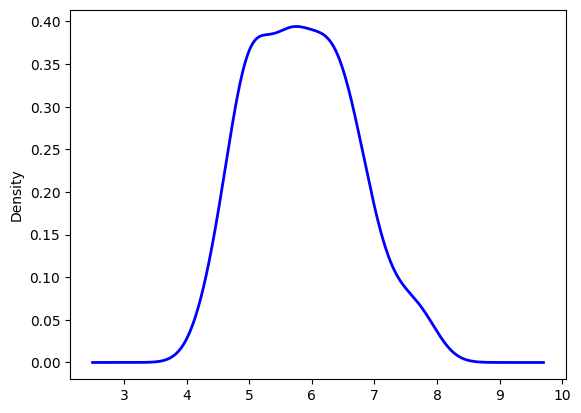

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris(as_frame=True)
df = iris.frame


# Creating the visulization
sepal_series = df['sepal length (cm)']
sepal_series.plot.density(bw_method='scott', color='blue', linestyle='-', linewidth=2)

plt.show()



<Axes: ylabel='Density'>

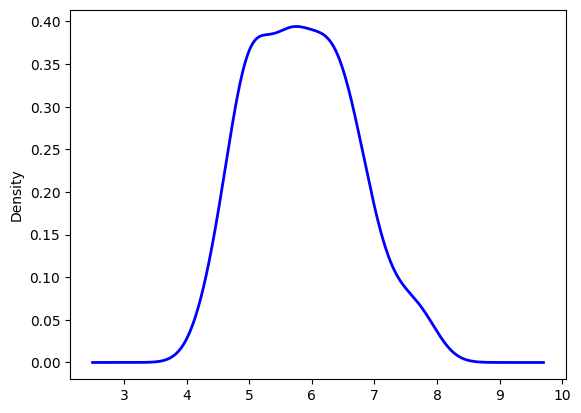

In [2]:
# The KDE Methods
sepal_series.plot.kde(bw_method='scott', color='blue', linestyle='-', linewidth=2)

Create multiple density plots (overlay) for comparison (e.g., by category)

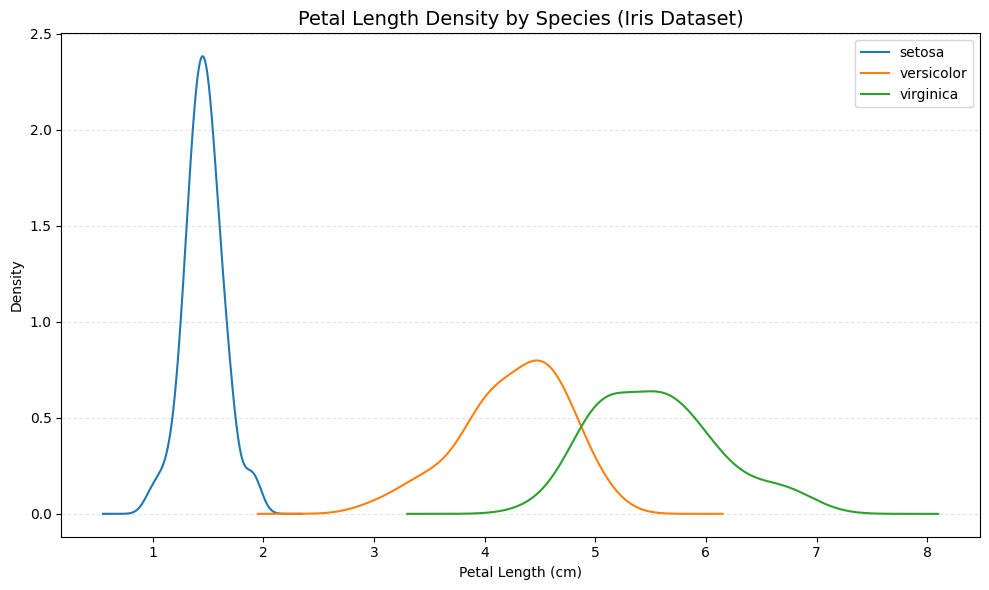

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()


df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['species'] = [iris.target_names[i] for i in iris.target]


plt.figure(figsize=(10, 6))


df.groupby('species')['petal length (cm)'].plot(kind='kde', legend=True)

plt.title('Petal Length Density by Species (Iris Dataset)', fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

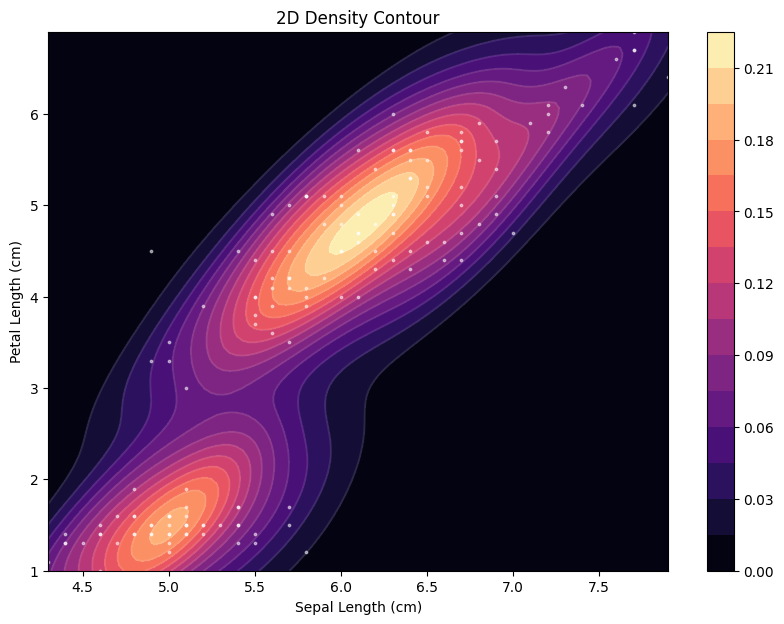

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

x = df['sepal length (cm)']
y = df['petal length (cm)']

xy = np.vstack([x, y])
kde = gaussian_kde(xy)

x_grid, y_grid = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
z_grid = kde(np.vstack([x_grid.flatten(), y_grid.flatten()])).reshape(x_grid.shape)

plt.figure(figsize=(10, 7))

contour_filled = plt.contourf(x_grid, y_grid, z_grid, levels=20, cmap='magma')
plt.contour(x_grid, y_grid, z_grid, levels=20, colors='white', alpha=0.1)

plt.colorbar(contour_filled)
plt.scatter(x, y, s=3, color='white', alpha=0.5)

plt.title('2D Density Contour')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')

plt.show()